In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier

In [4]:
df = pd.read_csv("../data/dataset/dataset02_fixed.csv")
df.dtypes

Unnamed: 0                           int64
customer_tenure                    float64
avg_order_amount                   float64
total_order_amounts_60d            float64
total_payment_amounts_60d          float64
total_payments_60d                 float64
failed_payment_rate_60d            float64
days_until_end_from_snapshot       float64
is_auto_renew                      float64
is_downgrade                       float64
plan_tier                            int64
subscription_age_days              float64
total_interactions_all_time        float64
opened_rate_all_time               float64
clicked_rate_all_time              float64
converted_rate_all_time            float64
total_interactions_60d             float64
opened_rate_60d                    float64
total_usage_all_time               float64
avg_usage_duration_all_time        float64
total_usage_60d                    float64
avg_usage_duration_60d             float64
days_since_last_completed_order    float64
avg_order_a

In [5]:
X = df.copy()
y = df["churn"].copy()
X.drop(columns=["Unnamed: 0", "churn"], inplace=True)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 1. Xác định param cho thuật toán HistGradianBoosting:

In [7]:
pipe = Pipeline([
    ('model', HistGradientBoostingClassifier())
])
HGB_finder = GridSearchCV(
    estimator=pipe,
    param_grid={
        "model__learning_rate": [0.05, 0.1],
        "model__max_iter": [100, 200],
        "model__max_leaf_nodes": [15, 31],
        "model__min_samples_leaf": [20, 50],
    },
    scoring={"precision": make_scorer(precision_score),
             "recall": make_scorer(recall_score),
             "AUC": "roc_auc"
            },
    refit="AUC",
    cv=4
)

In [8]:
HGB_finder.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_iter': [100, 200], 'model__max_leaf_nodes': [15, 31], 'model__min_samples_leaf': [20, 50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'AUC': 'roc_auc', 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'AUC'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See

In [9]:
pd.DataFrame(HGB_finder.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__min_samples_leaf,params,split0_test_precision,...,mean_test_recall,std_test_recall,rank_test_recall,split0_test_AUC,split1_test_AUC,split2_test_AUC,split3_test_AUC,mean_test_AUC,std_test_AUC,rank_test_AUC
0,0.234818,0.084945,0.033348,0.014530,0.05,100,15,20,"{'model__learning_rate': 0.05, 'model__max_ite...",0.831169,...,0.516362,0.060613,15,0.974192,0.968139,0.979369,0.976690,0.974598,0.004154,7
1,0.190102,0.016418,0.021749,0.001939,0.05,100,15,50,"{'model__learning_rate': 0.05, 'model__max_ite...",0.831169,...,0.514169,0.064380,16,0.973500,0.967539,0.980777,0.976772,0.974647,0.004846,6
2,0.274284,0.027695,0.022773,0.004477,0.05,100,31,20,"{'model__learning_rate': 0.05, 'model__max_ite...",0.802198,...,0.544851,0.083466,6,0.975307,0.966802,0.979669,0.976448,0.974556,0.004754,8
3,0.250297,0.019004,0.021497,0.000848,0.05,100,31,50,"{'model__learning_rate': 0.05, 'model__max_ite...",0.812500,...,0.527326,0.057702,13,0.973999,0.965037,0.980739,0.976336,0.974028,0.005727,12
4,0.264171,0.003991,0.026017,0.002766,0.05,200,15,20,"{'model__learning_rate': 0.05, 'model__max_ite...",0.809524,...,0.531636,0.080033,12,0.971717,0.967188,0.979176,0.977503,0.973896,0.004760,13
5,0.274362,0.005342,0.026132,0.002220,0.05,200,15,50,"{'model__learning_rate': 0.05, 'model__max_ite...",0.839506,...,0.540408,0.060793,8,0.973286,0.968116,0.980923,0.976890,0.974804,0.004713,3
6,0.440879,0.014143,0.027733,0.000547,0.05,200,31,20,"{'model__learning_rate': 0.05, 'model__max_ite...",0.776596,...,0.549199,0.083960,2,0.974124,0.967884,0.980174,0.976843,0.974756,0.004509,4
7,0.542325,0.175101,0.028773,0.001905,0.05,200,31,50,"{'model__learning_rate': 0.05, 'model__max_ite...",0.829268,...,0.549199,0.050093,2,0.974724,0.966131,0.981107,0.976908,0.974717,0.005463,5
8,0.154996,0.007344,0.017384,0.000965,0.10,100,15,20,"{'model__learning_rate': 0.1, 'model__max_iter...",0.816092,...,0.555759,0.069953,1,0.972305,0.968223,0.980498,0.976607,0.974408,0.004599,11
9,0.159633,0.005977,0.019566,0.003282,0.10,100,15,50,"{'model__learning_rate': 0.1, 'model__max_iter...",0.788235,...,0.540408,0.064179,8,0.972614,0.967373,0.980667,0.977026,0.974420,0.004968,10


In [10]:
HGB = HGB_finder.best_estimator_

## 2. Xác định param cho RandomForest

In [11]:
pipe = Pipeline([
    ('model', RandomForestClassifier(bootstrap=True))
])

RFC_finder = GridSearchCV(
    estimator=pipe,
    param_grid={
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 20],
        "model__max_features": ["sqrt", None],
        "model__max_samples": [0.7, None],
        "model__class_weight": ["balanced", None]
    },
    scoring={"precision": make_scorer(precision_score),
             "recall": make_scorer(recall_score),
             "AUC": "roc_auc"
            },
    refit="AUC",
    cv=3
)
        

In [12]:
RFC_finder.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', None], 'model__max_depth': [10, 20], 'model__max_features': ['sqrt', None], 'model__max_samples': [0.7, None], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'AUC': 'roc_auc', 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'AUC'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all pro

In [13]:
pd.DataFrame(RFC_finder.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__class_weight,param_model__max_depth,param_model__max_features,param_model__max_samples,param_model__n_estimators,params,...,split2_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_AUC,split1_test_AUC,split2_test_AUC,mean_test_AUC,std_test_AUC,rank_test_AUC
0,0.420559,0.128562,0.060265,0.024717,balanced,10,sqrt,0.7,100,"{'model__class_weight': 'balanced', 'model__ma...",...,0.823529,0.860036,0.027042,6,0.961265,0.963017,0.963831,0.962704,0.001071,46
1,0.731148,0.036814,0.077126,0.008567,balanced,10,sqrt,0.7,200,"{'model__class_weight': 'balanced', 'model__ma...",...,0.830065,0.855636,0.018081,8,0.963157,0.961924,0.962987,0.962689,0.000546,47
2,1.123044,0.112725,0.100504,0.004774,balanced,10,sqrt,0.7,300,"{'model__class_weight': 'balanced', 'model__ma...",...,0.836601,0.862200,0.018882,5,0.962943,0.964030,0.964306,0.963760,0.000588,43
3,0.363931,0.007395,0.038307,0.001360,balanced,10,sqrt,None,100,"{'model__class_weight': 'balanced', 'model__ma...",...,0.803922,0.842535,0.027827,12,0.960864,0.961085,0.962599,0.961516,0.000771,48
4,0.713127,0.005185,0.070436,0.002209,balanced,10,sqrt,None,200,"{'model__class_weight': 'balanced', 'model__ma...",...,0.816993,0.846893,0.021814,10,0.962997,0.963722,0.964416,0.963712,0.000580,44
5,1.133129,0.023360,0.096842,0.002955,balanced,10,sqrt,None,300,"{'model__class_weight': 'balanced', 'model__ma...",...,0.816993,0.846893,0.023715,10,0.961853,0.963876,0.963559,0.963096,0.000888,45
6,0.724504,0.030600,0.042427,0.005109,balanced,10,NaN,0.7,100,"{'model__class_weight': 'balanced', 'model__ma...",...,0.849673,0.881909,0.024176,2,0.966052,0.968994,0.962147,0.965731,0.002805,40
7,1.362971,0.010378,0.052040,0.002083,balanced,10,NaN,0.7,200,"{'model__class_weight': 'balanced', 'model__ma...",...,0.830065,0.873180,0.032324,3,0.967463,0.968941,0.962542,0.966315,0.002735,37
8,2.101352,0.006511,0.071529,0.000912,balanced,10,NaN,0.7,300,"{'model__class_weight': 'balanced', 'model__ma...",...,0.843137,0.884116,0.031937,1,0.967971,0.968142,0.962373,0.966162,0.002680,38
9,0.810820,0.023961,0.034013,0.003829,balanced,10,NaN,None,100,"{'model__class_weight': 'balanced', 'model__ma...",...,0.856209,0.866543,0.010878,4,0.967266,0.967324,0.962597,0.965729,0.002215,41


In [14]:
RFC = RFC_finder.best_estimator_

## 3. Tìm param cho LogisticRegression:

In [15]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])
LR_finder = GridSearchCV(
    estimator=pipe,
    param_grid={
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "saga"],
        "model__class_weight": [{0: 1, 1: v} for v in range(1, 10)],
    },
    scoring={"precision": make_scorer(precision_score),
             "recall": make_scorer(recall_score),
             "AUC": "roc_auc"
            },
    refit="AUC",
    cv=4
)

In [16]:
LR_finder.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2}, ...], 'model__solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'AUC': 'roc_auc', 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'AUC'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary

In [17]:
pd.DataFrame(LR_finder.cv_results_).sort_values(["rank_test_AUC"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__solver,params,split0_test_precision,split1_test_precision,...,mean_test_recall,std_test_recall,rank_test_recall,split0_test_AUC,split1_test_AUC,split2_test_AUC,split3_test_AUC,mean_test_AUC,std_test_AUC,rank_test_AUC
35,0.206774,0.060990,0.011472,0.001080,0.10,"{0: 1, 1: 9}",saga,"{'model__C': 0.1, 'model__class_weight': {0: 1...",0.380531,0.378995,...,0.757056,0.019605,4,0.901357,0.915139,0.905369,0.920996,0.910715,0.007769,1
34,0.029816,0.006192,0.018363,0.004436,0.10,"{0: 1, 1: 9}",lbfgs,"{'model__C': 0.1, 'model__class_weight': {0: 1...",0.380531,0.378995,...,0.757056,0.019605,4,0.901328,0.915098,0.905333,0.921014,0.910693,0.007784,2
52,0.034190,0.004245,0.015682,0.001033,1.00,"{0: 1, 1: 9}",lbfgs,"{'model__C': 1, 'model__class_weight': {0: 1, ...",0.379464,0.373874,...,0.757037,0.023352,6,0.900525,0.916661,0.904727,0.920772,0.910671,0.008309,3
70,0.043700,0.003800,0.015221,0.001135,10.00,"{0: 1, 1: 9}",lbfgs,"{'model__C': 10, 'model__class_weight': {0: 1,...",0.379464,0.372197,...,0.759211,0.026617,1,0.900454,0.916690,0.904864,0.920625,0.910658,0.008268,4
71,1.069570,0.169360,0.010775,0.001473,10.00,"{0: 1, 1: 9}",saga,"{'model__C': 10, 'model__class_weight': {0: 1,...",0.379464,0.372197,...,0.759211,0.026617,1,0.900353,0.916756,0.904787,0.920719,0.910654,0.008353,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54,0.030154,0.007846,0.015809,0.000745,10.00,"{0: 1, 1: 1}",lbfgs,"{'model__C': 10, 'model__class_weight': {0: 1,...",0.650794,0.681818,...,0.341228,0.049722,65,0.902207,0.893055,0.898641,0.907290,0.900298,0.005190,68
2,0.015844,0.002129,0.016589,0.000723,0.01,"{0: 1, 1: 2}",lbfgs,"{'model__C': 0.01, 'model__class_weight': {0: ...",0.542857,0.445783,...,0.428814,0.065124,63,0.898843,0.879493,0.905024,0.912590,0.898988,0.012263,69
3,0.090110,0.030095,0.012288,0.001357,0.01,"{0: 1, 1: 2}",saga,"{'model__C': 0.01, 'model__class_weight': {0: ...",0.542857,0.445783,...,0.428814,0.065124,63,0.898760,0.879291,0.905042,0.912684,0.898944,0.012372,70
1,0.104704,0.035518,0.010987,0.001041,0.01,"{0: 1, 1: 1}",saga,"{'model__C': 0.01, 'model__class_weight': {0: ...",0.833333,0.714286,...,0.192525,0.022016,71,0.892431,0.856036,0.898362,0.899036,0.886466,0.017756,71


In [18]:
LR = LR_finder.best_estimator_

## 4. Gộp vào stack

In [19]:
stack = StackingClassifier(
    estimators=[
        ("hgb", HGB),
        ("rfc", RFC),
        ("lr", LR)
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", stack)
])

stack_finder = GridSearchCV(
    estimator=pipe,
    param_grid={
        "model__final_estimator__C": [0.1, 1, 10],
        "model__passthrough": [False, True]
    },
    scoring={"precision": make_scorer(precision_score),
             "recall": make_scorer(recall_score),
             "AUC": "roc_auc"
            },
    refit="AUC",
    cv=4
)


In [20]:
stack_finder.fit(X_train, y_train)

/home/asus/training/week3/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/asus/training/week3/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/asus/training/week3/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/asus/training/week3/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/asus/training/week3/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/asus/training/

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ict_proba'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__final_estimator__C': [0.1, 1, ...], 'model__passthrough': [False, True]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'AUC': 'roc_auc', 'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'AUC'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchange

In [21]:
pd.DataFrame(stack_finder.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__final_estimator__C,param_model__passthrough,params,split0_test_precision,split1_test_precision,split2_test_precision,...,mean_test_recall,std_test_recall,rank_test_recall,split0_test_AUC,split1_test_AUC,split2_test_AUC,split3_test_AUC,mean_test_AUC,std_test_AUC,rank_test_AUC
0,15.681084,7.228060,0.334968,0.116911,0.1,False,"{'model__final_estimator__C': 0.1, 'model__pas...",0.444915,0.438298,0.449339,...,0.901564,0.012684,6,0.958916,0.962458,0.972216,0.975039,0.967157,0.006666,5
1,9.646776,0.733871,0.178989,0.044637,0.1,True,"{'model__final_estimator__C': 0.1, 'model__pas...",0.434959,0.436214,0.439130,...,0.927727,0.025960,2,0.958167,0.960526,0.969108,0.974314,0.965529,0.006504,6
2,10.181823,0.784815,0.259321,0.114064,1.0,False,"{'model__final_estimator__C': 1, 'model__passt...",0.445378,0.439331,0.452586,...,0.916895,0.012777,4,0.960306,0.965061,0.974213,0.976348,0.968982,0.006562,2
3,15.930737,4.354452,0.245725,0.079702,1.0,True,"{'model__final_estimator__C': 1, 'model__passt...",0.438017,0.436214,0.444444,...,0.929939,0.012568,1,0.964300,0.962173,0.972614,0.975198,0.968571,0.005465,3
4,9.256083,0.140813,0.542841,0.354986,10.0,False,"{'model__final_estimator__C': 10, 'model__pass...",0.436214,0.432773,0.444915,...,0.916857,0.009727,5,0.963171,0.966885,0.973244,0.975894,0.969799,0.005036,1
5,12.420573,5.123740,6.873989,7.018089,10.0,True,"{'model__final_estimator__C': 10, 'model__pass...",0.429752,0.440678,0.453390,...,0.919050,0.011289,3,0.960021,0.963147,0.972947,0.975752,0.967967,0.006553,4


In [22]:
final_model = stack_finder.best_estimator_

In [32]:
y_pred = final_model.predict(X_test)

In [25]:
precision_score(y_test, y_pred)

0.4212962962962963

In [26]:
recall_score(y_test, y_pred)

0.9381443298969072

In [27]:
roc_auc_score(y_test, y_pred)

0.9272101421755132

In [28]:
accuracy_score(y_test, y_pred)

0.9176100628930818

In [29]:
import joblib
joblib.dump(final_model, "predict_churn_model.joblib")

['predict_churn_model.joblib']

In [39]:
import json

dtypes_json = X_train.dtypes.astype(str).to_dict()

print(json.dumps(dtypes_json, indent=2, ensure_ascii=False))

{
  "customer_tenure": "float64",
  "avg_order_amount": "float64",
  "total_order_amounts_60d": "float64",
  "total_payment_amounts_60d": "float64",
  "total_payments_60d": "float64",
  "failed_payment_rate_60d": "float64",
  "days_until_end_from_snapshot": "float64",
  "is_auto_renew": "float64",
  "is_downgrade": "float64",
  "plan_tier": "int64",
  "subscription_age_days": "float64",
  "total_interactions_all_time": "float64",
  "opened_rate_all_time": "float64",
  "clicked_rate_all_time": "float64",
  "converted_rate_all_time": "float64",
  "total_interactions_60d": "float64",
  "opened_rate_60d": "float64",
  "total_usage_all_time": "float64",
  "avg_usage_duration_all_time": "float64",
  "total_usage_60d": "float64",
  "avg_usage_duration_60d": "float64",
  "days_since_last_completed_order": "float64",
  "avg_order_amount_60d": "float64",
  "avg_payment_amount_60d": "float64",
  "subscription_expired": "float64",
  "opened_rate_change": "float64",
  "clicked_rate_change": "float6

In [6]:
X_test.to_csv("../data/dataset/dataset01_X_test.csv")

In [34]:
thresholds = [0.1 * v for v in range (1, 11)]

/home/asus/training/week3/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


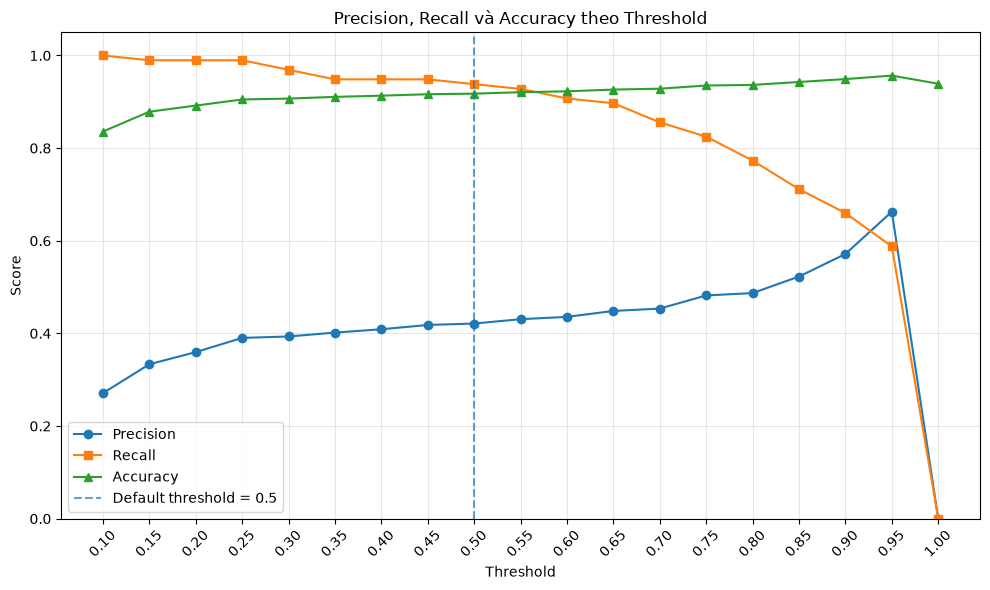

In [48]:
thresholds = np.arange(0.1, 1.05, 0.05)
y_prob = final_model.predict_proba(X_test)[:, 1]   # xác suất của class 1

precision_list = []
recall_list = []
accuracy_list = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    accuracy_list.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision_list, marker="o", label="Precision")
plt.plot(thresholds, recall_list, marker="s", label="Recall")
plt.plot(thresholds, accuracy_list, marker="^", label="Accuracy")

# Threshold mặc định của sklearn
plt.axvline(x=0.5, linestyle="--", alpha=0.7, label="Default threshold = 0.5")

plt.title("Precision, Recall và Accuracy theo Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.xticks(thresholds, rotation=45)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
print(y_test.shape, y_pred.shape)

(1590,) (1590, 2)


In [40]:
print(y_pred)

[[1 0]
 [0 1]
 [1 0]
 ...
 [1 0]
 [1 0]
 [1 0]]
